# Feature Engineering 

- Aggeration of the dataset which transform the transaction data we got into customer base dataset 

In [171]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 

In [172]:
cleaned_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\cleaned_df.csv",dtype={"StockCode":"str"})

In [173]:
cleaned_df["Sales"] = cleaned_df["Quantity"] * cleaned_df["Price"]

In [174]:
cleaned_df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1/12/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,1/12/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1/12/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1/12/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1/12/2010 8:26,3.39,17850.0,United Kingdom,20.34


# Generate aggregate df with RFM framework 

In [175]:
agg_cleaned_df = cleaned_df.groupby("Customer ID").agg(
    Country = ("Country", "first"),
    Total_sales = ("Sales", "sum"),
    Frequency = ("Invoice","nunique"), # nunique = number of unique number 
    LastInvoiceDate = ("InvoiceDate", "max")
).reset_index() # reset_index() is use to reset the customer ID to normal column as it currently set as index 

In [176]:
agg_cleaned_df = agg_cleaned_df[agg_cleaned_df["Total_sales"] > 0] # filter out all sales with 0 or less than 0 

In [177]:
# Convert Last Invoice date to datetime format first 
agg_cleaned_df["LastInvoiceDate"] = pd.to_datetime(agg_cleaned_df["LastInvoiceDate"],format = "%d/%m/%Y %H:%M",errors="coerce")

In [178]:
agg_cleaned_df["Reference_date"] = agg_cleaned_df["LastInvoiceDate"].max() + pd.Timedelta(days=1)  # Anchor point with max date + 1 day so most recent customer still has meaningdul non zero recency value 

In [179]:
# Convert both string column into datetime data type
agg_cleaned_df["Reference_date"] = pd.to_datetime(agg_cleaned_df["Reference_date"],errors="coerce")

# Define the recency column
agg_cleaned_df["Recency"] = (agg_cleaned_df["Reference_date"] - agg_cleaned_df["LastInvoiceDate"]).dt.days

In [180]:
agg_cleaned_df.info()
agg_cleaned_df.head(5)

agg_cleaned_df.to_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\aggregate_df.csv",index=False)

<class 'pandas.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      4334 non-null   float64       
 1   Country          4334 non-null   str           
 2   Total_sales      4334 non-null   float64       
 3   Frequency        4334 non-null   int64         
 4   LastInvoiceDate  4334 non-null   datetime64[us]
 5   Reference_date   4334 non-null   datetime64[us]
 6   Recency          4334 non-null   int64         
dtypes: datetime64[us](2), float64(2), int64(2), str(1)
memory usage: 237.1 KB


In [181]:
agg_cleaned_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\aggregate_df.csv")

# Identify Outlier and distribution 

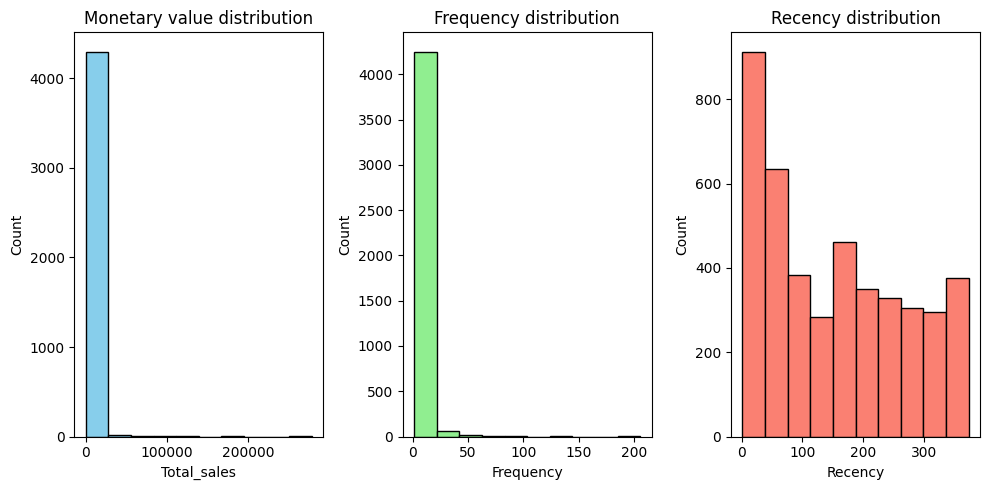

In [182]:
# Identify the distribution with histogram visualization

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.hist(agg_cleaned_df["Total_sales"], bins=10,color="skyblue",edgecolor="black")
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")
plt.ylabel("Count")

plt.subplot(1,3,2)
plt.hist(agg_cleaned_df["Frequency"], bins=10,color="lightgreen",edgecolor="black")
plt.title("Frequency distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
plt.hist(agg_cleaned_df["Recency"], bins=10,color="salmon",edgecolor="black")
plt.title("Recency distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

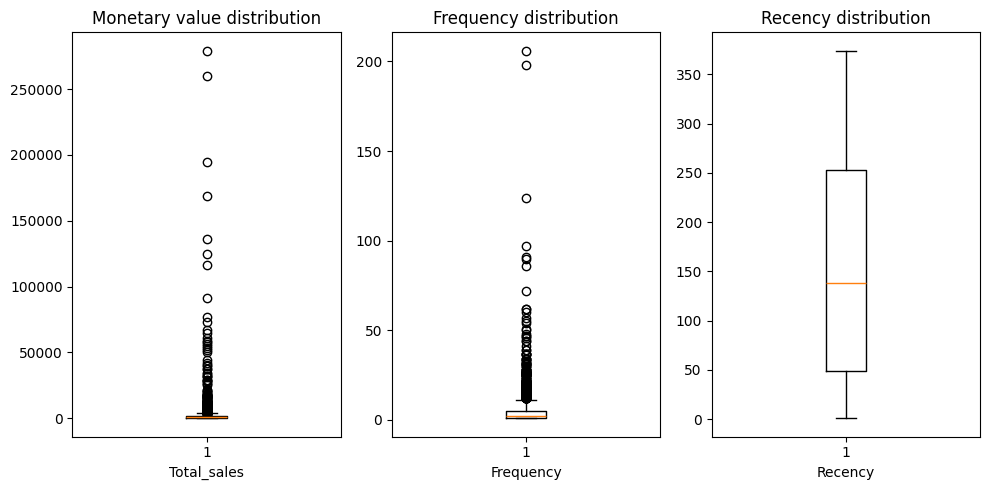

In [183]:
# Identify the outlier with boxplot

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.boxplot(agg_cleaned_df["Total_sales"])
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")


plt.subplot(1,3,2)
plt.boxplot(agg_cleaned_df["Frequency"])
plt.title("Frequency distribution")
plt.xlabel("Frequency")


plt.subplot(1,3,3)
plt.boxplot(agg_cleaned_df["Recency"])
plt.title("Recency distribution")
plt.xlabel("Recency")


plt.tight_layout()
plt.show()

In [184]:
# Determine monetary total sales column outlier with IQR

S_01  = agg_cleaned_df["Total_sales"].quantile(0.25) 
S_03  = agg_cleaned_df["Total_sales"].quantile(0.75)
S_IQR = S_03 - S_01

S_outlier_df = agg_cleaned_df[(agg_cleaned_df["Total_sales"]>(S_03 + 1.5 * S_IQR))]
S_outlier_df.describe().T

S_outlier_df.to_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\Monetary_outlier_df.csv",index=False)

In [185]:
# Determine Frequency column Outlier with InterQuatileRange 

F_Q1 = agg_cleaned_df["Frequency"].quantile(0.25)
F_Q3 = agg_cleaned_df["Frequency"].quantile(0.75)
F_IQR = F_Q3 - F_Q1

F_outlier_df = agg_cleaned_df[(agg_cleaned_df["Frequency"] > (F_Q3 + 1.5 * F_IQR))]
F_outlier_df.describe()

F_outlier_df.to_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\Frequency_outlier_df.csv",index=False)

In [186]:
# Determine Recency column Outlier with InterQuatileRange 

R_Q1 = agg_cleaned_df["Recency"].quantile(0.25)
R_Q3 = agg_cleaned_df["Recency"].quantile(0.75)
R_IQR = R_Q3 - R_Q1

R_outlier_df = agg_cleaned_df[(agg_cleaned_df["Recency"] > (R_Q3 + 1.5 * R_IQR))]

# Recency show normal outlier behavior 

In [187]:
# Outlier separation as outlier will distord the centroid so outlier seperation could give better cluster
# this technique is called two-stage segmentation which standard K-Means on the majority, manual rule-based labelling on extremes  
# Do not seperate the outlier of recency as it show normal outlier genuinely inactive customer which is valuable info for segmentation.
non_outlier_df = agg_cleaned_df[
    (~ agg_cleaned_df.index.isin(F_outlier_df.index)) & 
    (~ agg_cleaned_df.index.isin(S_outlier_df.index))
]

non_outlier_df.describe()

,Customer ID,Total_sales,Frequency,Recency
count,3866.000000,3866.000000,3866.000000,3866.000000
mean,15324.358769,851.925034,2.758924,154.451888
std,1710.150045,795.365663,2.173063,115.367589
min,12348.000000,3.750000,1.000000,1.000000
25%,13850.250000,276.607500,1.000000,47.000000
50%,15333.500000,565.920000,2.000000,135.000000
75%,16799.000000,1178.287500,4.000000,250.000000
max,18287.000000,3619.170000,11.000000,374.000000


In [188]:
non_outlier_df.to_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\non_outlier_df.csv",index=False)
print("sucessfully!")

sucessfully!


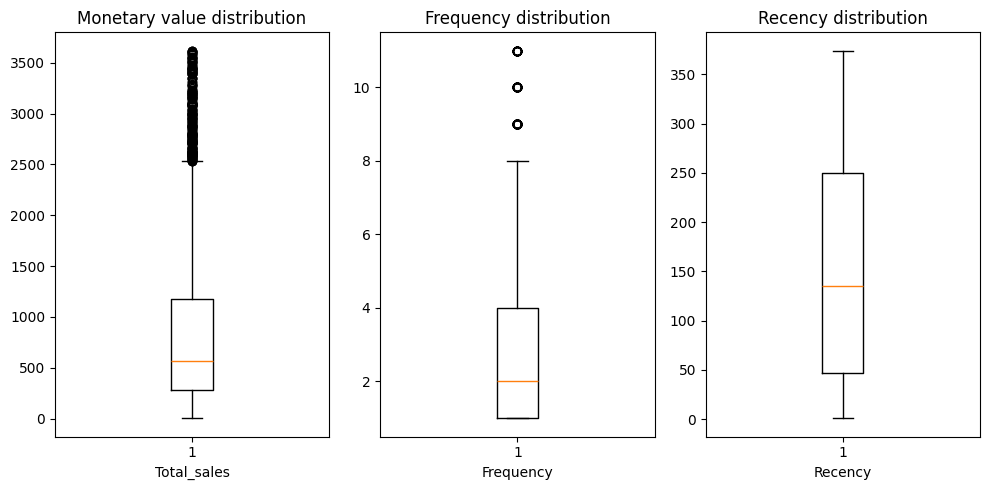

In [189]:
# To check outlier again after filtering 

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.boxplot(non_outlier_df["Total_sales"])
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")


plt.subplot(1,3,2)
plt.boxplot(non_outlier_df["Frequency"])
plt.title("Frequency distribution")
plt.xlabel("Frequency")


plt.subplot(1,3,3)
plt.boxplot(non_outlier_df["Recency"])
plt.title("Recency distribution")
plt.xlabel("Recency")


plt.tight_layout()
plt.show()

Text(0.5, 0.92, '3D Scatter plot of Customer data')

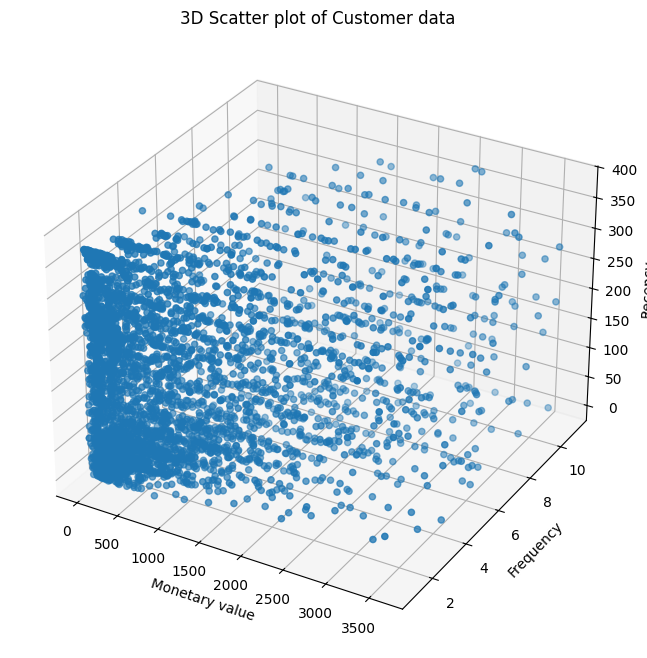

In [190]:
# Visualise the non outlier dataframe in 3D scatter plot (Not-scale yet)
 
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outlier_df["Total_sales"],non_outlier_df["Frequency"],non_outlier_df["Recency"])
ax.set_xlabel("Monetary value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter plot of Customer data")


# Log Transformation 

- RFM features are right-skewed which most customer cluster at low end (tail stretch far right)

- Apply log transform to compress the long tail which making the distribution more symmetric before standardscaler standardises it.

- Order = Raw data > Remove outlier > Log trasform > normalization

In [191]:
log_transformed_df = non_outlier_df.copy()

log_transformed_df["Total_sales"]   = np.log1p(log_transformed_df["Total_sales"])
log_transformed_df["Frequency"]     = np.log1p(log_transformed_df["Frequency"])
log_transformed_df["Recency"]       = np.log1p(log_transformed_df["Recency"])

log_transformed_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3866.0,15324.358769,1710.150045,12348.000000,13850.250000,15333.500000,16799.000000,18287.000000
Total_sales,3866.0,6.304086,1.002185,1.558145,5.626208,6.340218,7.072666,8.194276
Frequency,3866.0,1.189240,0.497426,0.693147,0.693147,1.098612,1.609438,2.484907
Recency,3866.0,4.570134,1.202123,0.693147,3.871201,4.912655,5.525453,5.926926


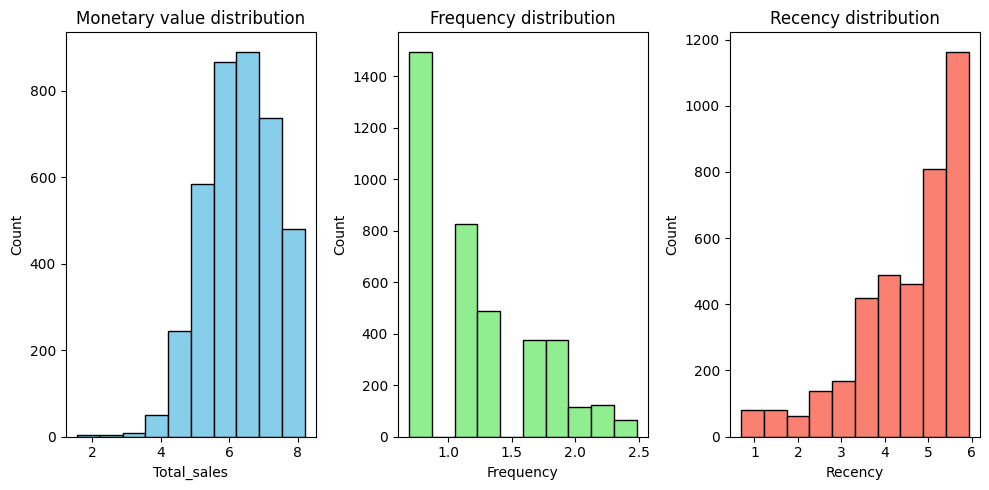

In [192]:
# To check the distribution after log transformation

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.hist(log_transformed_df["Total_sales"], bins=10,color="skyblue",edgecolor="black")
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")
plt.ylabel("Count")

plt.subplot(1,3,2)
plt.hist(log_transformed_df["Frequency"], bins=10,color="lightgreen",edgecolor="black")
plt.title("Frequency distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
plt.hist(log_transformed_df["Recency"], bins=10,color="salmon",edgecolor="black")
plt.title("Recency distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [193]:
# Data transformation with standard scaler 
# Without scale the monetary id completely dominate which the centroid would draw more to monetary value 
# create a unfair goruping, we want our algorithm to treat all features with equal weight and important

scaler = StandardScaler()
rfm_scaled_data = scaler.fit_transform(log_transformed_df[["Total_sales","Frequency","Recency"]])
rfm_scaled_data # this return a series of array

array([[ 0.96510527,  0.84485379,  0.79147451],
       [ 0.97909915, -0.99744908, -1.3098545 ],
       [-0.61449255, -0.99744908,  0.97312006],
       ...,
       [-1.89566746, -0.99744908,  0.5273623 ],
       [-1.11413071, -0.18221708,  0.22800339],
       [ 1.21001201,  0.39619924, -0.65388208]], shape=(3866, 3))

In [194]:
# convert into dataframe

scaled_data_df =pd.DataFrame(rfm_scaled_data,index=log_transformed_df.index,columns=["Monetary_value","Frequency","Recency"])
scaled_data_df

,Monetary_value,Frequency,Recency
2,0.965105,0.844854,0.791475
3,0.979099,-0.997449,-1.309855
4,-0.614493,-0.997449,0.973120
5,0.928716,1.789848,-0.798039
6,-1.800575,-0.997449,0.626369
...,...,...,...
4328,-1.137533,-0.997449,-0.210194
4329,-1.100018,-0.997449,0.882784
4330,-1.895667,-0.997449,0.527362
4331,-1.114131,-0.182217,0.228003


Text(0.5, 0.92, '3D scatter plot for customer data')

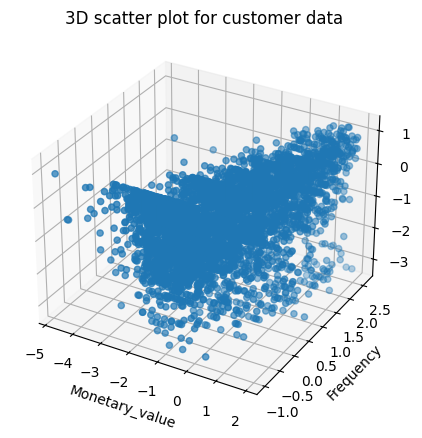

In [195]:
# Visualised the scaled dataframe

fig = plt.figure(figsize=(5,10))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(scaled_data_df["Monetary_value"],scaled_data_df["Frequency"],scaled_data_df["Recency"])
ax.set_xlabel("Monetary_value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D scatter plot for customer data")

In [196]:
scaled_data_df.to_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\scaled_data_df.csv",index=False)
print("save succefully!")

save succefully!
